# Regresión Lineal: Coste de un incidente de seguridad

En este ejercicio se explican los fundamentos básicos de la regresión lineal aplicada a un caso de uso sencillo relacionado con la Ciberseguridad.

## Enunciado del ejercicio

El ejercicio consiste en predecir el coste de un incidente de seguridad en base al número de equipos que se han visto afectados. El conjunto de datos es generado de manera aleatoria.

### 0. Imports

# Instalacion de librerías externas
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install scikit-learn

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

### 1. Generación del conjunto de datos

In [1]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

print("La longitud del conjunto de datos es:", len(X))

La longitud del conjunto de datos es: 100


### 2. Visualización del conjunto de datos

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

# las imagenes aparecen dentro del Notebook

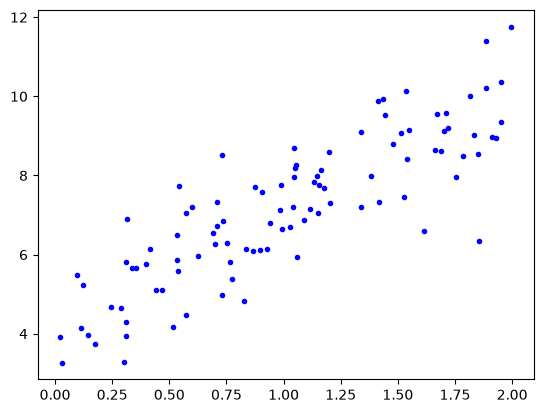

In [3]:
plt.plot(X, y, "b.")
plt.show()

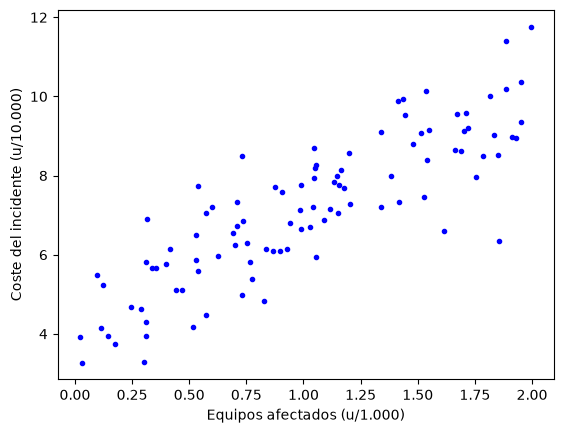

In [4]:
plt.plot(X, y, "b.")
plt.xlabel("Equipos afectados (u/1.000)")
plt.ylabel("Coste del incidente (u/10.000)")
plt.show()

### 3. Modificación del conjunto de datos

In [7]:
import pandas as pd

In [8]:
# Convertimos nuestro conjunto de datos en un diccionario
data = {'n_equipos_afectados': X.flatten(), 'coste': y.flatten()}

# Se construye el DataFrame
df = pd.DataFrame(data)
df.head(10)

,n_equipos_afectados,coste
0,1.040448,7.205791
1,0.111841,4.139420
2,1.046033,8.689910
3,1.534593,10.138192
4,1.116067,7.159709
5,0.468715,5.112081
6,1.150986,7.057431
7,0.122528,5.239170
8,1.720419,9.200462
9,1.670499,9.556034


In [9]:
# Escalado del número de equipos afectados
df['n_equipos_afectados'] = df['n_equipos_afectados'] * 1000
df['n_equipos_afectados'] = df['n_equipos_afectados'].astype('int')

# Escalado del coste
df['coste'] = df['coste'] * 10000
df['coste'] = df['coste'].astype('int')
df.head(10)

,n_equipos_afectados,coste
0,1040,72057
1,111,41394
2,1046,86899
3,1534,101381
4,1116,71597
5,468,51120
6,1150,70574
7,122,52391
8,1720,92004
9,1670,95560


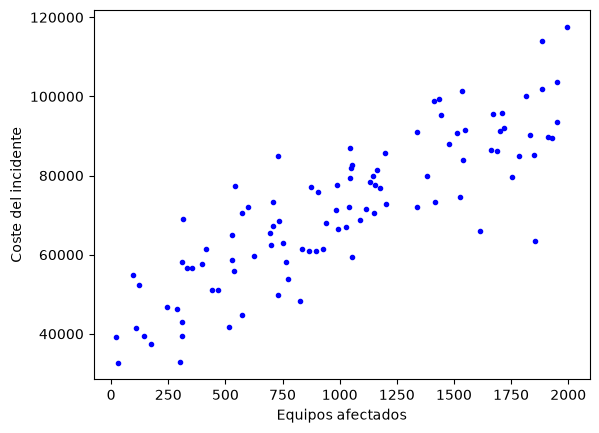

In [10]:
# Representación gráfica del conjunto de datos
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 4. Construcción del modelo

Entrenamos nuestro algoritmo de Regresión Lieal

Algorítmo basado en **Aprendizaje Supervisado**

In [11]:
from sklearn.linear_model import LinearRegression

In [12]:
# Construcción del modelo y ajuste de la función hipótesis
# La función fit() va a ser equivalente a entrenar
lin_reg = LinearRegression()
lin_reg.fit(df['n_equipos_afectados'].values.reshape(-1, 1), df['coste'].values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[28.7]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.238e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5497.61]


In [13]:
# Parámetro theta 0
lin_reg.intercept_
print(lin_reg.intercept_)

42381.046374828744


In [14]:
# Parámetro theta 1
lin_reg.coef_
print(lin_reg.coef_)

[28.69675761]


In [15]:
# Predicción para el valor mínimo y máximo del conjunto de datos de entrenamiento
X_min_max = np.array([[df["n_equipos_afectados"].min()], [df["n_equipos_afectados"].max()]])
y_train_pred = lin_reg.predict(X_min_max)

In [16]:
print(min(X*1000), max(X*1000))
print(y_train_pred)

[22.79673745] [1995.73700122]
[43012.37504219 99631.07780167]


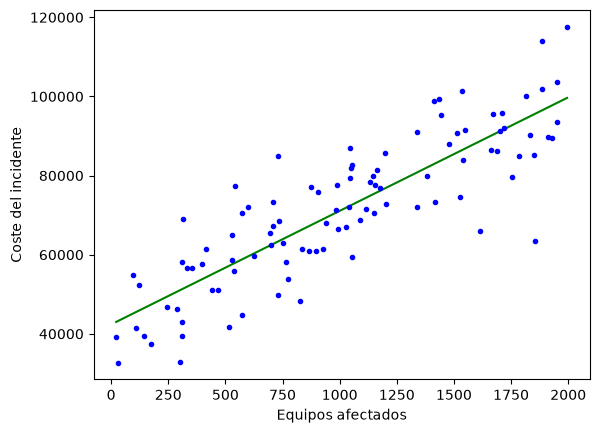

In [17]:
# Representación gráfica de la función hipótesis generada
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

### 5. Predicción de nuevos ejemplos

In [18]:
x_new = np.array([[1300]]) # 1300 equipos afectados

# Predicción del coste que tendría el incidente
coste = lin_reg.predict(x_new) 

print("El coste del incidente sería:", int(coste[0]), "$")

El coste del incidente sería: 79686 $


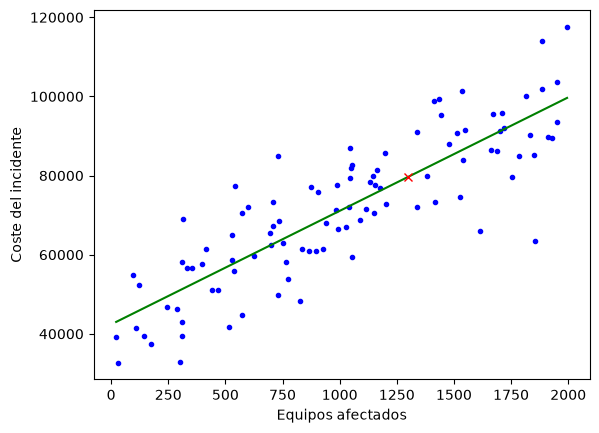

In [19]:
plt.plot(df['n_equipos_afectados'], df['coste'], "b.")
plt.plot(X_min_max, y_train_pred, "g-")
plt.plot(x_new, coste, "rx")
plt.xlabel("Equipos afectados")
plt.ylabel("Coste del incidente")
plt.show()

## 6. Regresión lineal con descenso de gradiente

Ahora estimaremos la misma recta de regresión, pero sin utilizar `LinearRegression` para el ajuste.

El modelo sigue siendo

$$
\hat{y}=\beta_0+\beta_1x.
$$

Para evitar problemas numéricos debidos a la escala de `n_equipos_afectados`, primero estandarizamos únicamente la variable $x$:

$$
z=\frac{x-\bar{x}}{s_x}.
$$

El descenso de gradiente repetirá cuatro pasos:

1. calcular predicciones;
2. calcular residuos;
3. calcular los gradientes del MSE;
4. actualizar $\beta_0$ y $\beta_1$.


In [20]:
# Datos que ya fueron usados por Scikit-Learn
x = df["n_equipos_afectados"].to_numpy(dtype=float)
y_real = df["coste"].to_numpy(dtype=float)

# Estandarizamos x para que el descenso de gradiente sea estable
media_x = x.mean()
desv_x = x.std()

z = (x - media_x) / desv_x

# Valores iniciales
beta0_std = 0.0
beta1_std = 0.0

eta = 0.01          # tasa de aprendizaje
epocas = 2000
costos = []

for epoca in range(epocas):
    # 1. Predicción
    y_hat = beta0_std + beta1_std * z

    # 2. Residuos
    errores = y_real - y_hat

    # Guardamos el MSE
    mse = np.mean(errores ** 2)
    costos.append(mse)

    # 3. Gradientes del MSE
    grad_b0 = -2 * np.mean(errores)
    grad_b1 = -2 * np.mean(errores * z)

    # 4. Actualización de parámetros
    beta0_std -= eta * grad_b0
    beta1_std -= eta * grad_b1

print("Parámetros obtenidos sobre x estandarizada:")
print("beta0* =", beta0_std)
print("beta1* =", beta1_std)


Parámetros obtenidos sobre x estandarizada:
beta0* = 71493.61999999965
beta1* = 15776.345442889959


### Volver a la escala original de $x$

Como el descenso de gradiente se realizó usando la variable estandarizada $z$, convertimos los coeficientes a la escala original de número de equipos.

Si

$$
\hat y=\beta_0^*+\beta_1^*z,
\qquad
z=\frac{x-\bar{x}}{s_x},
$$

entonces

$$
\hat y=
\left(\beta_0^*-\beta_1^*\frac{\bar{x}}{s_x}\right)
+
\left(\frac{\beta_1^*}{s_x}\right)x.
$$


In [ ]:
# Coeficientes del descenso de gradiente en la escala original
beta1_gd = beta1_std / desv_x
beta0_gd = beta0_std - beta1_std * media_x / desv_x

print("Parámetros del descenso de gradiente en la escala original:")
print(f"beta0 = {beta0_gd:.6f}")
print(f"beta1 = {beta1_gd:.6f}")


## 7. Curva de aprendizaje del descenso de gradiente

La siguiente gráfica muestra cómo cambia el MSE a medida que avanzan las épocas.

Una disminución rápida seguida de una estabilización indica que el algoritmo está convergiendo.


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(costos)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Evolución del costo durante el descenso de gradiente")
plt.show()


## 8. Comparación: Scikit-Learn vs. descenso de gradiente

Ahora comparamos los parámetros estimados por ambos métodos.

- **Scikit-Learn** ajusta directamente el modelo lineal mediante procedimientos numéricos optimizados.
- **Descenso de gradiente** llega a la solución de forma iterativa, reduciendo el MSE época tras época.

Si el descenso de gradiente convergió correctamente, los valores de $\beta_0$ y $\beta_1$ deberían ser prácticamente iguales.


In [ ]:
# Parámetros de Scikit-Learn
beta0_sklearn = float(lin_reg.intercept_)
beta1_sklearn = float(lin_reg.coef_[0])

comparacion = pd.DataFrame({
    "Método": ["Scikit-Learn", "Descenso de gradiente"],
    "beta0 (intercepto)": [beta0_sklearn, beta0_gd],
    "beta1 (pendiente)": [beta1_sklearn, beta1_gd]
})

display(comparacion.round(6))

print("Diferencia absoluta en beta0:",
      abs(beta0_sklearn - beta0_gd))

print("Diferencia absoluta en beta1:",
      abs(beta1_sklearn - beta1_gd))


In [ ]:
# Comparamos también el error de ambos modelos
y_pred_sklearn = lin_reg.predict(x.reshape(-1, 1))
y_pred_gd = beta0_gd + beta1_gd * x

mse_sklearn = np.mean((y_real - y_pred_sklearn) ** 2)
mse_gd = np.mean((y_real - y_pred_gd) ** 2)

print(f"MSE Scikit-Learn:        {mse_sklearn:.4f}")
print(f"MSE Descenso gradiente:  {mse_gd:.4f}")


### Pequeño análisis de los parámetros

El parámetro $\beta_0$ es el **intercepto** de la recta. Representa el coste que el modelo estimaría cuando el número de equipos afectados es cero. Como el conjunto de datos puede no contener observaciones cercanas a cero, este parámetro debe interpretarse con precaución.

El parámetro $\beta_1$ es la **pendiente**. En este problema representa aproximadamente cuánto aumenta el coste esperado del incidente cuando se añade **un equipo afectado adicional**.

Los dos métodos deberían producir parámetros casi idénticos. Una diferencia muy pequeña se debe únicamente a que el descenso de gradiente es un procedimiento iterativo y se detiene después de un número finito de épocas.

Podemos generar automáticamente una interpretación usando los valores obtenidos en la ejecución:


In [ ]:
print(f"Scikit-Learn estima beta0 = {beta0_sklearn:.2f}")
print(f"Scikit-Learn estima beta1 = {beta1_sklearn:.4f}")
print()
print(f"Descenso de gradiente estima beta0 = {beta0_gd:.2f}")
print(f"Descenso de gradiente estima beta1 = {beta1_gd:.4f}")
print()

print(
    f"Interpretación de beta1: por cada equipo afectado adicional, "
    f"el coste esperado aumenta aproximadamente en ${beta1_sklearn:.2f}."
)

if abs(beta0_sklearn - beta0_gd) < 0.1 and abs(beta1_sklearn - beta1_gd) < 0.001:
    print(
        "Conclusión: ambos métodos llegaron prácticamente a la misma recta de regresión."
    )
else:
    print(
        "Los parámetros todavía presentan diferencias. "
        "Puede ser conveniente aumentar el número de épocas o revisar eta."
    )


## 9. Visualización de residuos

Los residuos se calculan como

$$
e_i=y_i-\hat y_i.
$$

En un ajuste lineal razonable deberían aparecer dispersos alrededor de cero, sin un patrón sistemático claramente visible.


In [ ]:
residuos = y_real - y_pred_sklearn

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_sklearn, residuos)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicción")
plt.ylabel("Residuo")
plt.title("Residuos vs. predicciones")
plt.show()


### ¿Qué observar en la gráfica de residuos?

- Una nube aproximadamente aleatoria alrededor de cero es una buena señal para un modelo lineal básico.
- Una **curvatura** puede sugerir que la relación entre las variables no es completamente lineal.
- Una forma de **embudo** puede indicar que la variabilidad de los errores cambia con el nivel de la predicción.
- Residuos muy alejados del resto pueden sugerir observaciones atípicas.

Esta gráfica no demuestra por sí sola que el modelo sea correcto, pero es una herramienta sencilla para detectar posibles problemas de ajuste.
